In [1]:
import os
import json
from glob import glob
from collections import defaultdict

import numpy as np
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 1e-4

DINO_FOLDER = "dataset/dinosaur"

MODEL_PATH = "models/stage2_dino_species.keras"
CLASS_MAP_PATH = "models/stage2_dino_classes.json"

In [2]:
X, y = [], []
class_to_idx = {}
idx_to_class = {}

def get_base_class(folder_name):
    return folder_name.split("_")[0]

grouped_folders = defaultdict(list)

In [3]:
for sub in os.listdir(DINO_FOLDER):
    full_path = os.path.join(DINO_FOLDER, sub)
    if os.path.isdir(full_path):
        base_class = get_base_class(sub)
        grouped_folders[base_class].append(full_path)

class_names = sorted(grouped_folders.keys())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

In [4]:
print("Визначенні класи:")
for cls, paths in grouped_folders.items():
    print(f"  {cls}: {len(paths)} папки")

Визначенні класи:
  Allosaurus: 1 папки
  Ankylosaurus: 2 папки
  Apatosaurus: 1 папки
  Archaeopteryx: 1 папки
  Argentinosaurus: 1 папки
  Atrociraptor: 1 папки
  Barosaurus: 1 папки
  Baryonyx: 1 папки
  Brachiosaurus: 2 папки
  Brontosaurus: 1 папки
  Carnotaurus: 1 папки
  Ceratosaurus: 1 папки
  Compsognathus: 2 папки
  Corythosaurus: 2 папки
  Dilophosaurus: 2 папки
  Dimetrodon: 1 папки
  Dimorphodon: 2 папки
  Diplodocus: 1 папки
  Europasaurus: 1 папки
  Gallimimus: 2 папки
  Giganotosaurus: 1 папки
  Iguanodon: 1 папки
  Lystrosaurus: 1 папки
  Maiasaura: 1 папки
  Mamenchisaurus: 1 папки
  Microceratus: 2 папки
  Mosasaurus: 1 папки
  Nasutoceratops: 1 папки
  Nodosaurus: 1 папки
  Oviraptor: 1 папки
  Pachycephalosaurus: 2 папки
  Parasaurolophus: 2 папки
  Pteranodon: 1 папки
  Pterodactyl: 1 папки
  Pyroraptor: 1 папки
  Quetzalcoatlus: 1 папки
  Sinoceratops: 1 папки
  Spinosaurus: 2 папки
  Stegosaurus: 2 папки
  Stygimoloch: 1 папки
  Styracosaurus: 1 папки
  Therizin

In [5]:
os.makedirs("models", exist_ok=True)
with open(CLASS_MAP_PATH, "w", encoding="utf-8") as f:
    json.dump(idx_to_class, f, indent=2)

In [6]:
train_items = []
val_items = []
test_items = []

for cls, folders in grouped_folders.items():
    label = class_to_idx[cls]

    if len(folders) == 1:
        train_items.append((folders[0], label))
        continue

    train_f, temp_f = train_test_split(
        folders, test_size=0.3, random_state=42
    )

    if len(temp_f) > 1:
        val_f, test_f = train_test_split(
            temp_f, test_size=0.5, random_state=42
        )
    else:
        val_f = temp_f
        test_f = []

    train_items += [(f, label) for f in train_f]
    val_items += [(f, label) for f in val_f]
    test_items += [(f, label) for f in test_f]

In [7]:
def load_data(items):
    X, y = [], []
    for folder, label in items:
        paths = glob(f"{folder}/**/*.*", recursive=True)
        for path in paths:
            try:
                img = Image.open(path).convert("RGB").resize(IMG_SIZE)
                X.append(np.array(img))
                y.append(label)
            except:
                pass
    return np.array(X, dtype="float32"), np.array(y, dtype=np.int32)

In [8]:
X_train, y_train = load_data(train_items)
X_val, y_val = load_data(val_items)
X_test, y_test = load_data(test_items)

print("\nЗагальна кількість картинок:")
print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")


Загальна кількість картинок:
Train: 4276
Val: 2414
Test: 0


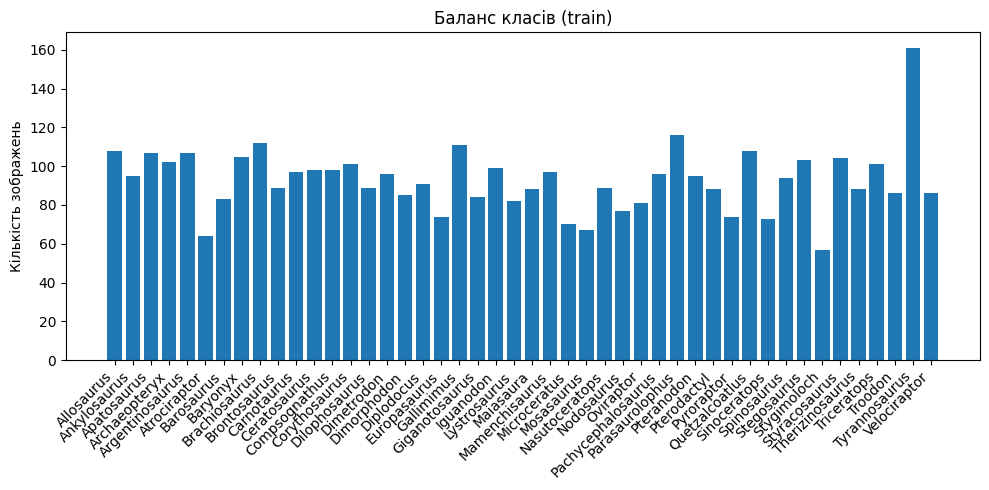

In [9]:
class_counts = {cls: 0 for cls in class_to_idx.keys()}

for label in y_train:
    class_name = idx_to_class[label]
    class_counts[class_name] += 1

labels = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Баланс класів (train)")
plt.ylabel("Кількість зображень")
plt.tight_layout()
plt.show()

In [10]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_flow = train_gen.flow(X_train, y_train, batch_size=BATCH_SIZE)
val_flow = val_gen.flow(X_val, y_val, batch_size=BATCH_SIZE)

In [11]:
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [12]:
from tensorflow.keras import layers, models, optimizers, regularizers
import tensorflow as tf

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [13]:
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,788,142 (94.56 MB)

 Trainable params: 1,196,334 (4.56 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [14]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

In [15]:
history1 = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/25
268/268 - 745s - 3s/step - accuracy: 0.0395 - loss: 4.2723 - val_accuracy: 0.1777 - val_loss: 3.4111 - learning_rate: 1.0000e-04
Epoch 2/25
268/268 - 589s - 2s/step - accuracy: 0.0975 - loss: 3.6588 - val_accuracy: 0.2817 - val_loss: 3.0825 - learning_rate: 1.0000e-04
Epoch 3/25
268/268 - 516s - 2s/step - accuracy: 0.1356 - loss: 3.3755 - val_accuracy: 0.3148 - val_loss: 2.8203 - learning_rate: 1.0000e-04
Epoch 4/25
268/268 - 511s - 2s/step - accuracy: 0.1724 - loss: 3.1410 - val_accuracy: 0.3604 - val_loss: 2.6213 - learning_rate: 1.0000e-04
Epoch 5/25
268/268 - 508s - 2s/step - accuracy: 0.2126 - loss: 2.9713 - val_accuracy: 0.4002 - val_loss: 2.4606 - learning_rate: 1.0000e-04
Epoch 6/25
268/268 - 507s - 2s/step - accuracy: 0.2268 - loss: 2.8444 - val_accuracy: 0.4221 - val_loss: 2.3256 - learning_rate: 1.0000e-04
Epoch 7/25
268/268 - 507s - 2s/step - accuracy: 0.2502 - loss: 2.7235 - val_accuracy: 0.4354 - val_loss: 2.2403 - learning_rate: 1.0000e-04
Epoch 8/25
268/268 -

In [16]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/50
268/268 - 1050s - 4s/step - accuracy: 0.4317 - loss: 1.9774 - val_accuracy: 0.6015 - val_loss: 1.6043 - learning_rate: 1.0000e-05
Epoch 2/50
268/268 - 1014s - 4s/step - accuracy: 0.4663 - loss: 1.8019 - val_accuracy: 0.6114 - val_loss: 1.5817 - learning_rate: 1.0000e-05
Epoch 3/50
268/268 - 1010s - 4s/step - accuracy: 0.4815 - loss: 1.7333 - val_accuracy: 0.6201 - val_loss: 1.5202 - learning_rate: 1.0000e-05
Epoch 4/50
268/268 - 1008s - 4s/step - accuracy: 0.4988 - loss: 1.6958 - val_accuracy: 0.6226 - val_loss: 1.5189 - learning_rate: 1.0000e-05
Epoch 5/50
268/268 - 1022s - 4s/step - accuracy: 0.5070 - loss: 1.6254 - val_accuracy: 0.6321 - val_loss: 1.4599 - learning_rate: 1.0000e-05
Epoch 6/50
268/268 - 1029s - 4s/step - accuracy: 0.5250 - loss: 1.5833 - val_accuracy: 0.6400 - val_loss: 1.4366 - learning_rate: 1.0000e-05
Epoch 7/50
268/268 - 1009s - 4s/step - accuracy: 0.5372 - loss: 1.5072 - val_accuracy: 0.6500 - val_loss: 1.3866 - learning_rate: 1.0000e-05
Epoch 8/50
26

In [19]:
print("\nТест:")
model.evaluate(X_val, y_val, verbose=2)


Тест:
76/76 - 160s - 2s/step - accuracy: 0.5994 - loss: 1.6629


[1.6629410982131958, 0.5994200706481934]

In [20]:
model.save(MODEL_PATH)